In [1]:
using Pkg
Pkg.activate("..")
using StaticArrays
using Eliashberg
using CairoMakie

println("Eliashberg loaded successfully!")

  Activating project at `~/Development/models/Eliashberg`

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


Eliashberg loaded successfully!


### Define a 1D Tight-Binding model (Perfect nesting condition)


In [5]:
t = 1.0
tp = 0.0
mu = 0.0
tb_model = TightBinding{1}(t, tp, mu)
kgrid = generate_1d_kgrid(100)
Nq = 60
# 产生一个均匀的 q 网格用于探测 BZ 内的不稳定点
qgrid = generate_1d_kgrid(Nq)

T_val = 0.1

0.1

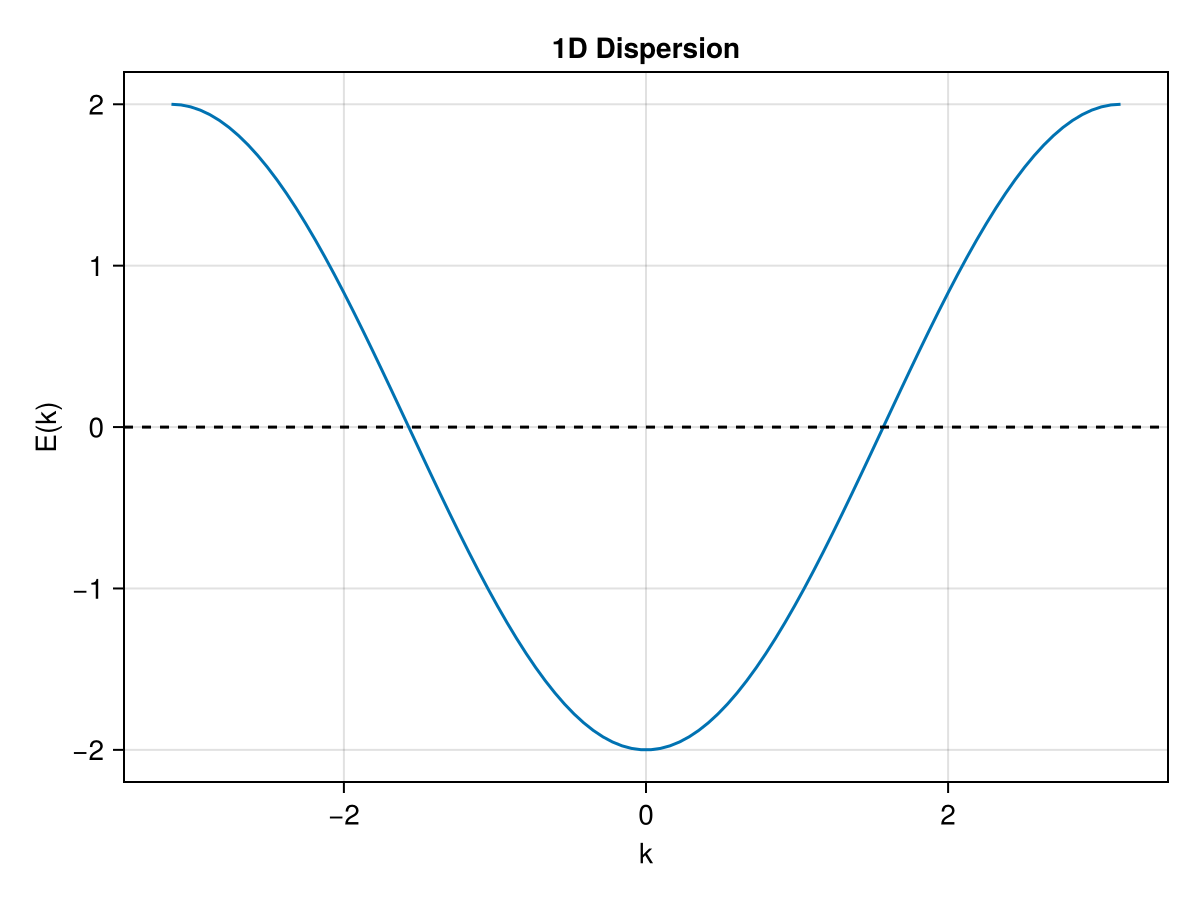

In [7]:
visualize_dispersion(tb_model, kgrid)

In [8]:

phi_values = range(0.0, 1.5, length=30)
T_val = 0.1

F_exact_vals = evaluate(action, phi_values, ExactTrLn(); T=T_val)
F_RPA_vals   = evaluate(action, phi_values, RPA(); T=T_val)
# Solve for the optimal ground state configuration dynamically using Optim
phi_gs_exact = solve_ground_state(action, ExactTrLn(); phi_guess=0.5)
phi_gs_rpa = solve_ground_state(action, RPA(); phi_guess=0.5)

println("Exact Ground state order parameter ϕ = ", phi_gs_exact)
println("RPA Ground state order parameter ϕ = ", phi_gs_rpa)

Exact Ground state order parameter ϕ = 0.37504494577068775
RPA Ground state order parameter ϕ = 2.361519249611284e34


In [9]:
Q = SVector{2, Float64}(pi, pi)
cdw = ChargeDensityWave(Q)
V_bare = 2.0
action = EffectiveAction(tb_model, cdw, kgrid, V_bare)

phi_values = range(0.0, 1.5, length=30)
T_val = 0.1

F_exact_vals = evaluate(action, phi_values, ExactTrLn(); T=T_val)
F_RPA_vals   = evaluate(action, phi_values, RPA(); T=T_val)

# Solve for the optimal ground state configuration dynamically using Optim
phi_gs_exact = solve_ground_state(action, ExactTrLn(); phi_guess=0.5)
phi_gs_rpa = solve_ground_state(action, RPA(); phi_guess=0.5)

println("Exact Ground state order parameter ϕ = ", phi_gs_exact)
println("RPA Ground state order parameter ϕ = ", phi_gs_rpa)

MethodError: MethodError: no method matching reconstructed_bands(::SVector{1, Float64}, ::Float64, ::ChargeDensityWave{2}, ::TightBinding{1})
The function `reconstructed_bands` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  reconstructed_bands(::SVector{D, Float64}, ::Float64, !Matched::ChargeDensityWave{D}, ::PhysicalModel) where D
   @ Eliashberg ~/Development/models/Eliashberg/src/fields.jl:11


In [5]:
landscape_data = scan_instability_landscape(tb_model, kgrid, qgrid; T=T_val)
landscape_matrix = reshape(landscape_data, Nq)
fig_ls = visualize_landscape(Val(1), qgrid, landscape_matrix)

┌ Info: Scanning instability landscape over 60 q-points...
└ @ Eliashberg /home/yimzhang/Development/models/Eliashberg/src/scanners.jl:21


MethodError: MethodError: no method matching visualize_landscape(::Val{1}, ::KGrid{1}, ::Vector{Float64})
The function `visualize_landscape` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  visualize_landscape(!Matched::Val{2}, !Matched::KGrid{2}, !Matched::Matrix{Float64}; axis, kwargs...)
   @ Eliashberg ~/Development/models/Eliashberg/src/visualization.jl:268


### Define a 2D Tight-Binding model (Perfect nesting condition)


In [2]:
t = 1.0
tp = 0.0
mu = 0.0
tb_model = TightBinding{2}(t, tp, mu)
kgrid = generate_2d_kgrid(100, 100) 

# --- B. 可视化静态景观 (Landscape) ---
Nq = 60
# 产生一个均匀的 q 网格用于探测 BZ 内的不稳定点
qgrid = generate_2d_kgrid(Nq, Nq)
smearing = FermiDiracSmearing(0.01) # T = 0.01

FermiDiracSmearing(0.01)

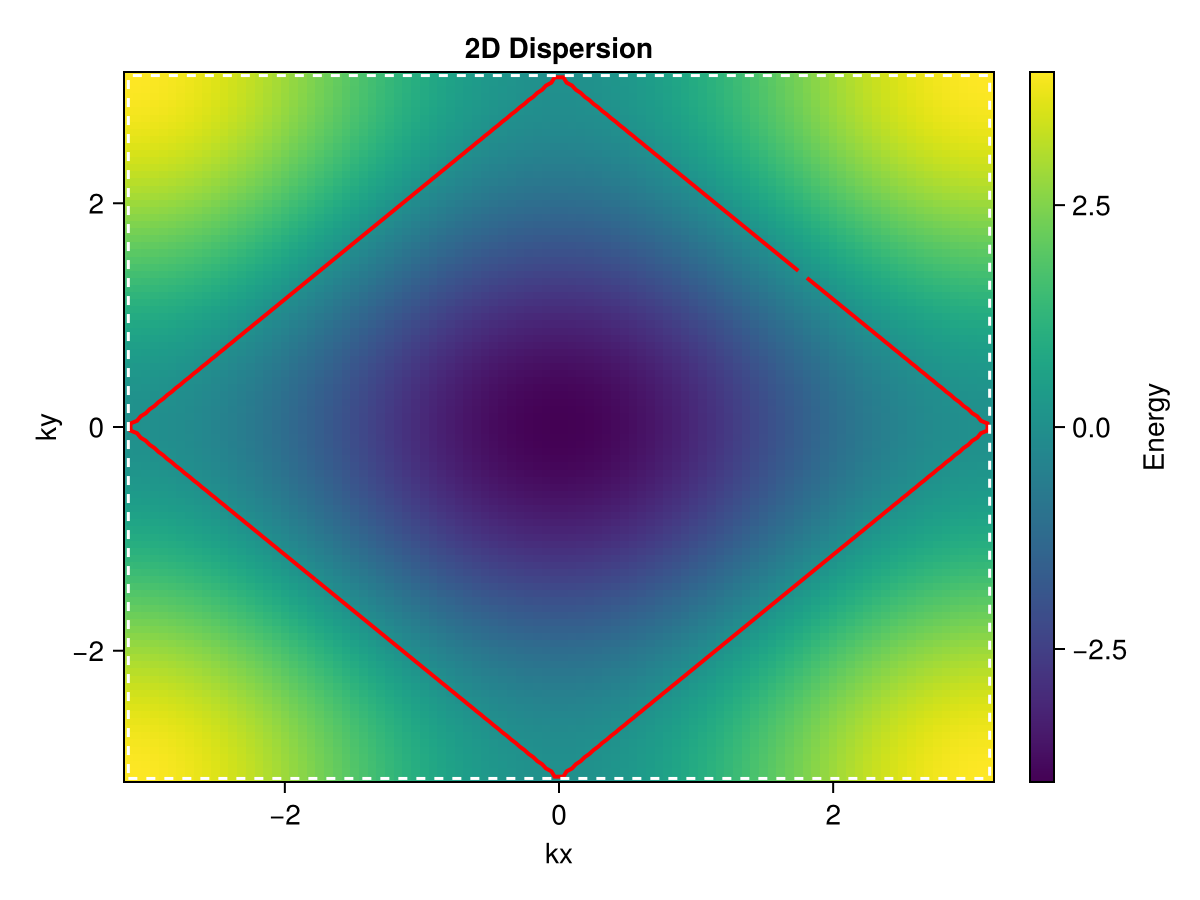

In [4]:
visualize_dispersion(tb_model, kgrid)

In [3]:
Q = SVector{2, Float64}(pi, pi)
cdw = ChargeDensityWave(Q)
V_bare = 2.0
action = EffectiveAction(tb_model, cdw, kgrid, V_bare)

phi_values = range(0.0, 1.5, length=30)
T_val = 0.1

F_exact_vals = evaluate(action, phi_values, ExactTrLn(); T=T_val)
F_RPA_vals   = evaluate(action, phi_values, RPA(); T=T_val)

# Solve for the optimal ground state configuration dynamically using Optim
phi_gs_exact = solve_ground_state(action, ExactTrLn(); phi_guess=0.5)
phi_gs_rpa = solve_ground_state(action, RPA(); phi_guess=0.5)

println("Exact Ground state order parameter ϕ = ", phi_gs_exact)
println("RPA Ground state order parameter ϕ = ", phi_gs_rpa)

Exact Ground state order parameter ϕ = 0.37504494577068775
RPA Ground state order parameter ϕ = 2.361519249611284e34


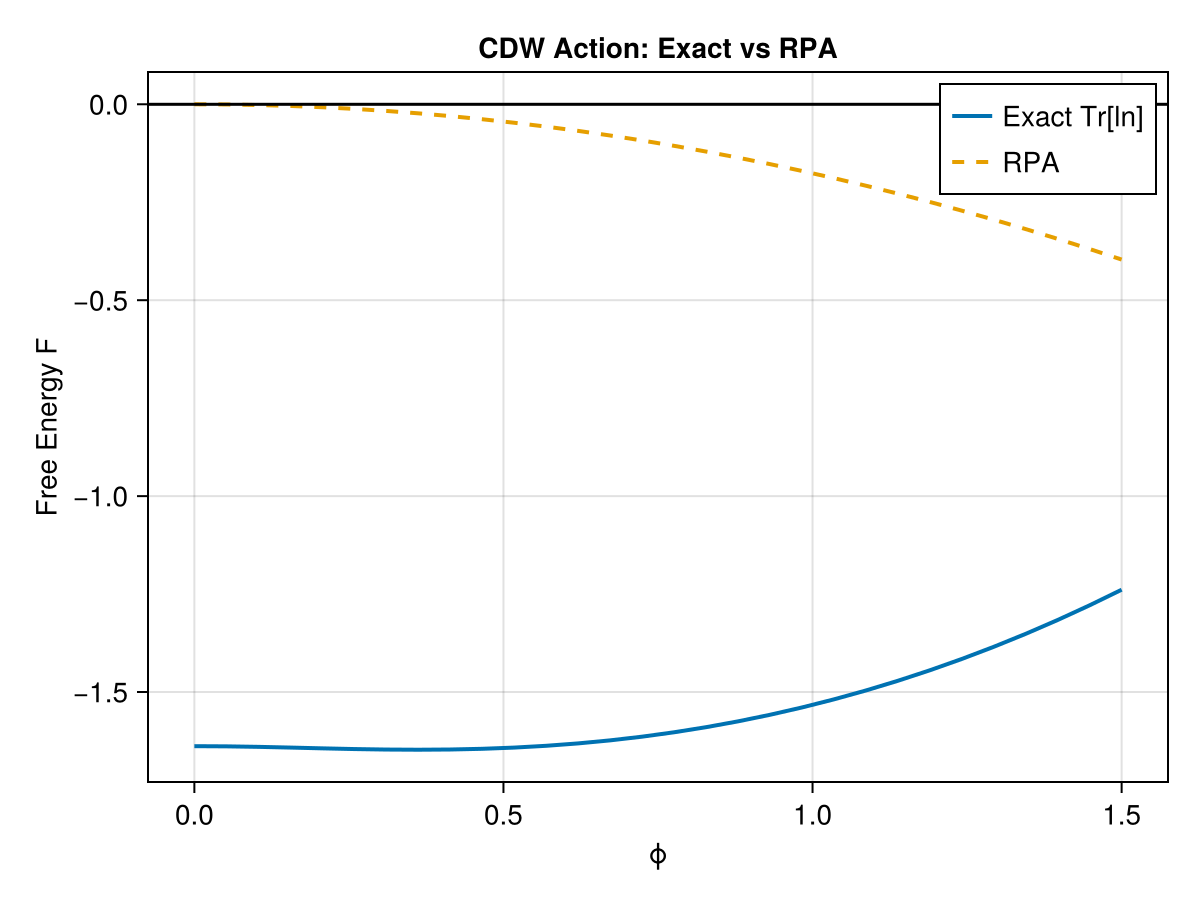

In [4]:
fig_action = Figure()
ax = Axis(fig_action[1, 1], xlabel = "ϕ", ylabel = "Free Energy F", title="CDW Action: Exact vs RPA")
lines!(ax, phi_values, F_exact_vals, label="Exact Tr[ln]", linewidth=2)
lines!(ax, phi_values, F_RPA_vals, label="RPA", linestyle=:dash, linewidth=2)
hlines!(ax, [0.0], color=:black)
axislegend(ax)
fig_action

┌ Info: Scanning instability landscape over 3600 q-points...
└ @ Eliashberg /home/yimzhang/Development/models/Eliashberg/src/scanners.jl:21


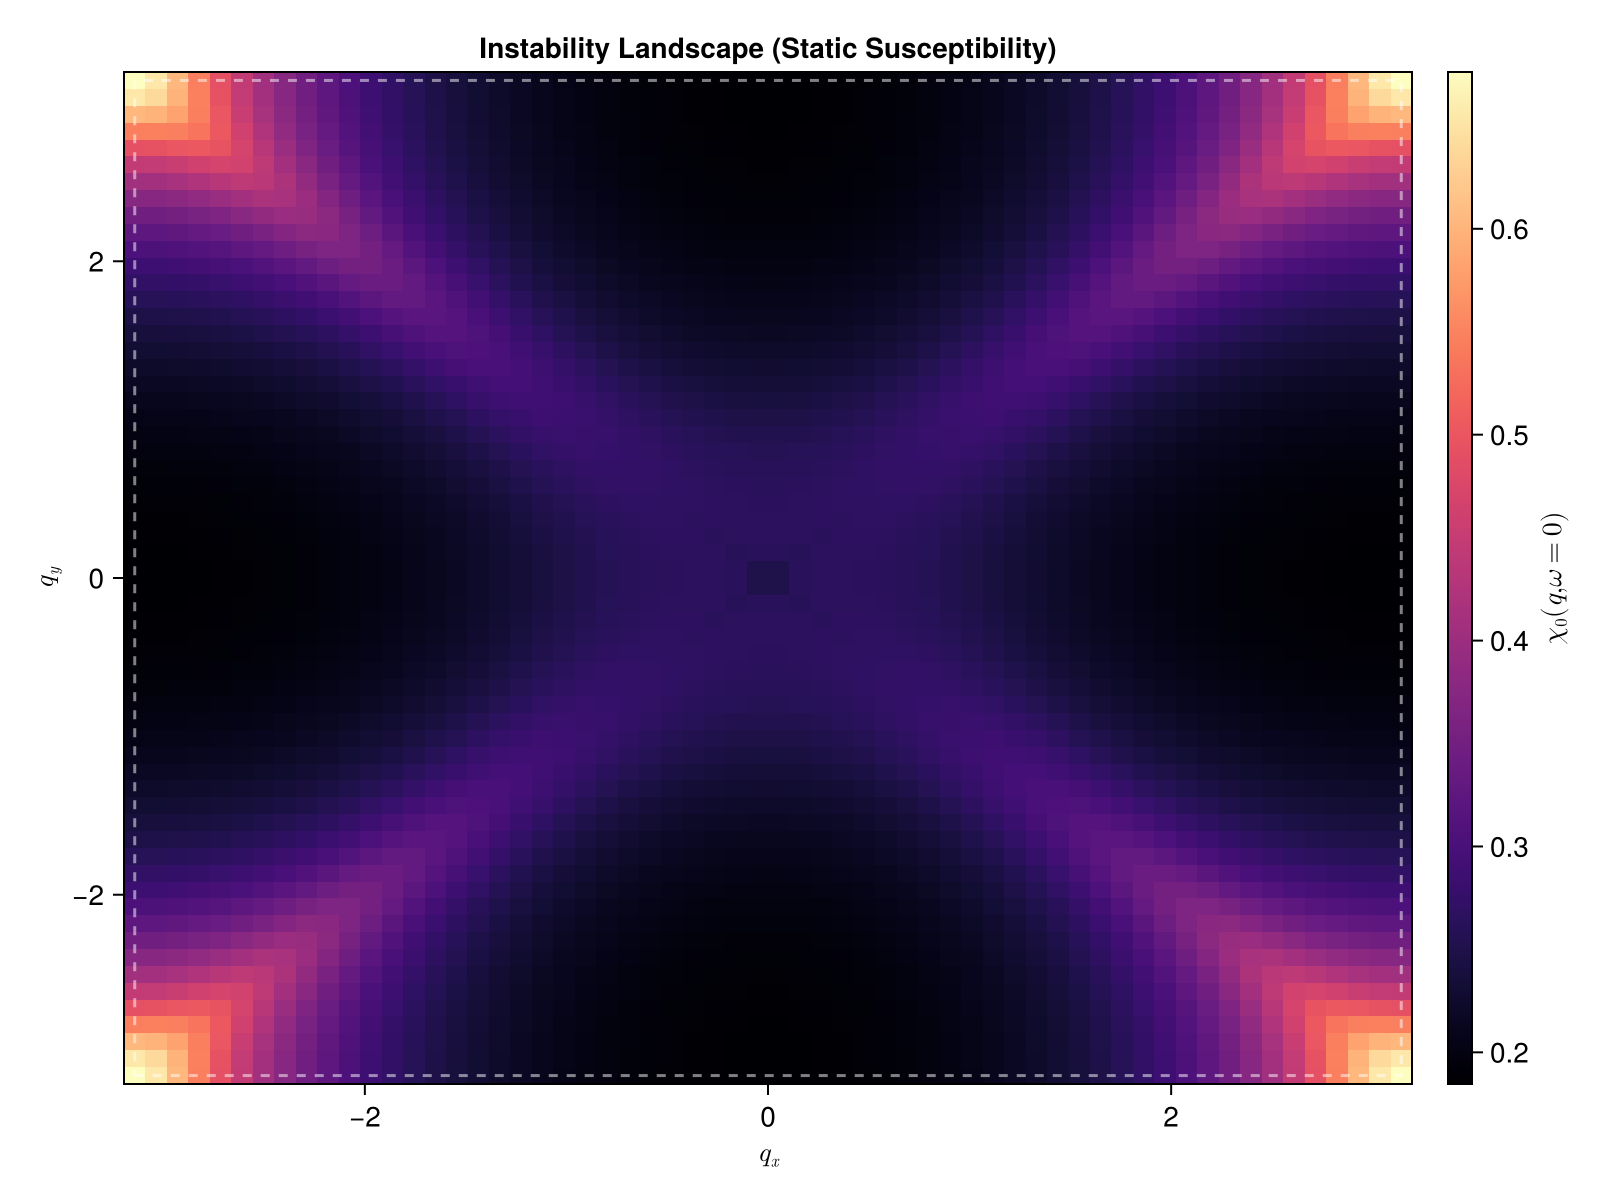

In [6]:
landscape_data = scan_instability_landscape(tb_model, kgrid, qgrid; T=T_val)
landscape_matrix = reshape(landscape_data, Nq, Nq)
fig_ls = visualize_landscape(Val(2), qgrid, landscape_matrix)

In [15]:
# 1. 定义高对称路径 (例如：Γ -> X -> M -> Γ)
nodes = [
    SVector{2, Float64}(0, 0),    # Γ
    SVector{2, Float64}(pi, 0),   # X
    SVector{2, Float64}(pi, pi),  # M
    SVector{2, Float64}(0, 0)     # Γ
]
labels = ["Γ", "X", "M", "Γ"]
qpath = generate_kpath(nodes, labels; n_pts_per_segment=40)
# 2. 定义能量/频率范围 ω
omegas = range(0.0, 2.5, length=100)
# 3. 执行动态谱扫描
# A(q, ω) 矩阵的大小为 (length(q_path), length(omegas))
spectral_matrix = scan_spectral_function(tb_model, kgrid, qpath, omegas; T=T_val, η=0.04)
# 4. 可视化扫描结果
# 该函数会自动根据 q_path 的节点添加高对称点标签和垂直分割线
fig_spectral = visualize_spectral_function(qpath, omegas, spectral_matrix)
display(fig_spectral)

MethodError: MethodError: no method matching length(::KPath{2})
The function `length` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  length(!Matched::Base.AsyncGenerator)
   @ Base asyncmap.jl:392
  length(!Matched::Base.MethodSpecializations)
   @ Base runtime_internals.jl:1680
  length(!Matched::ExponentialBackOff)
   @ Base error.jl:280
  ...


### Define a 3D Tight-Binding model (Perfect nesting condition)


In [5]:
t = 1.0
tp = 0.0
mu = 0.0
tb_model = TightBinding{3}(t, tp, mu)
grid_3d = generate_3d_kgrid(20, 20, 20)
smearing = FermiDiracSmearing(0.01) # T = 0.01

# 定义 3D 简立方的高对称点
Γ = SVector(0.0, 0.0, 0.0)
X = SVector(π, 0.0, 0.0)
M = SVector(π, π, 0.0)
R = SVector(π, π, π)

# 生成 KPath
# 路径：Γ -> X -> M -> Γ -> R
nodes = [Γ, X, M, Γ, R]
labels = ["Γ", "X", "M", "Γ", "R"]
path = generate_kpath(nodes, labels; n_pts_per_segment=50)



KPath{3}(SVector{3, Float64}[[0.0, 0.0, 0.0], [0.06283185307179587, 0.0, 0.0], [0.12566370614359174, 0.0, 0.0], [0.18849555921538758, 0.0, 0.0], [0.25132741228718347, 0.0, 0.0], [0.3141592653589793, 0.0, 0.0], [0.37699111843077515, 0.0, 0.0], [0.4398229715025711, 0.0, 0.0], [0.5026548245743669, 0.0, 0.0], [0.5654866776461628, 0.0, 0.0]  …  [2.57610597594363, 2.57610597594363, 2.57610597594363], [2.638937829015426, 2.638937829015426, 2.638937829015426], [2.701769682087222, 2.701769682087222, 2.701769682087222], [2.764601535159018, 2.764601535159018, 2.764601535159018], [2.827433388230814, 2.827433388230814, 2.827433388230814], [2.8902652413026098, 2.8902652413026098, 2.8902652413026098], [2.9530970943744053, 2.9530970943744053, 2.9530970943744053], [3.015928947446201, 3.015928947446201, 3.015928947446201], [3.078760800517997, 3.078760800517997, 3.078760800517997], [3.141592653589793, 3.141592653589793, 3.141592653589793]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 

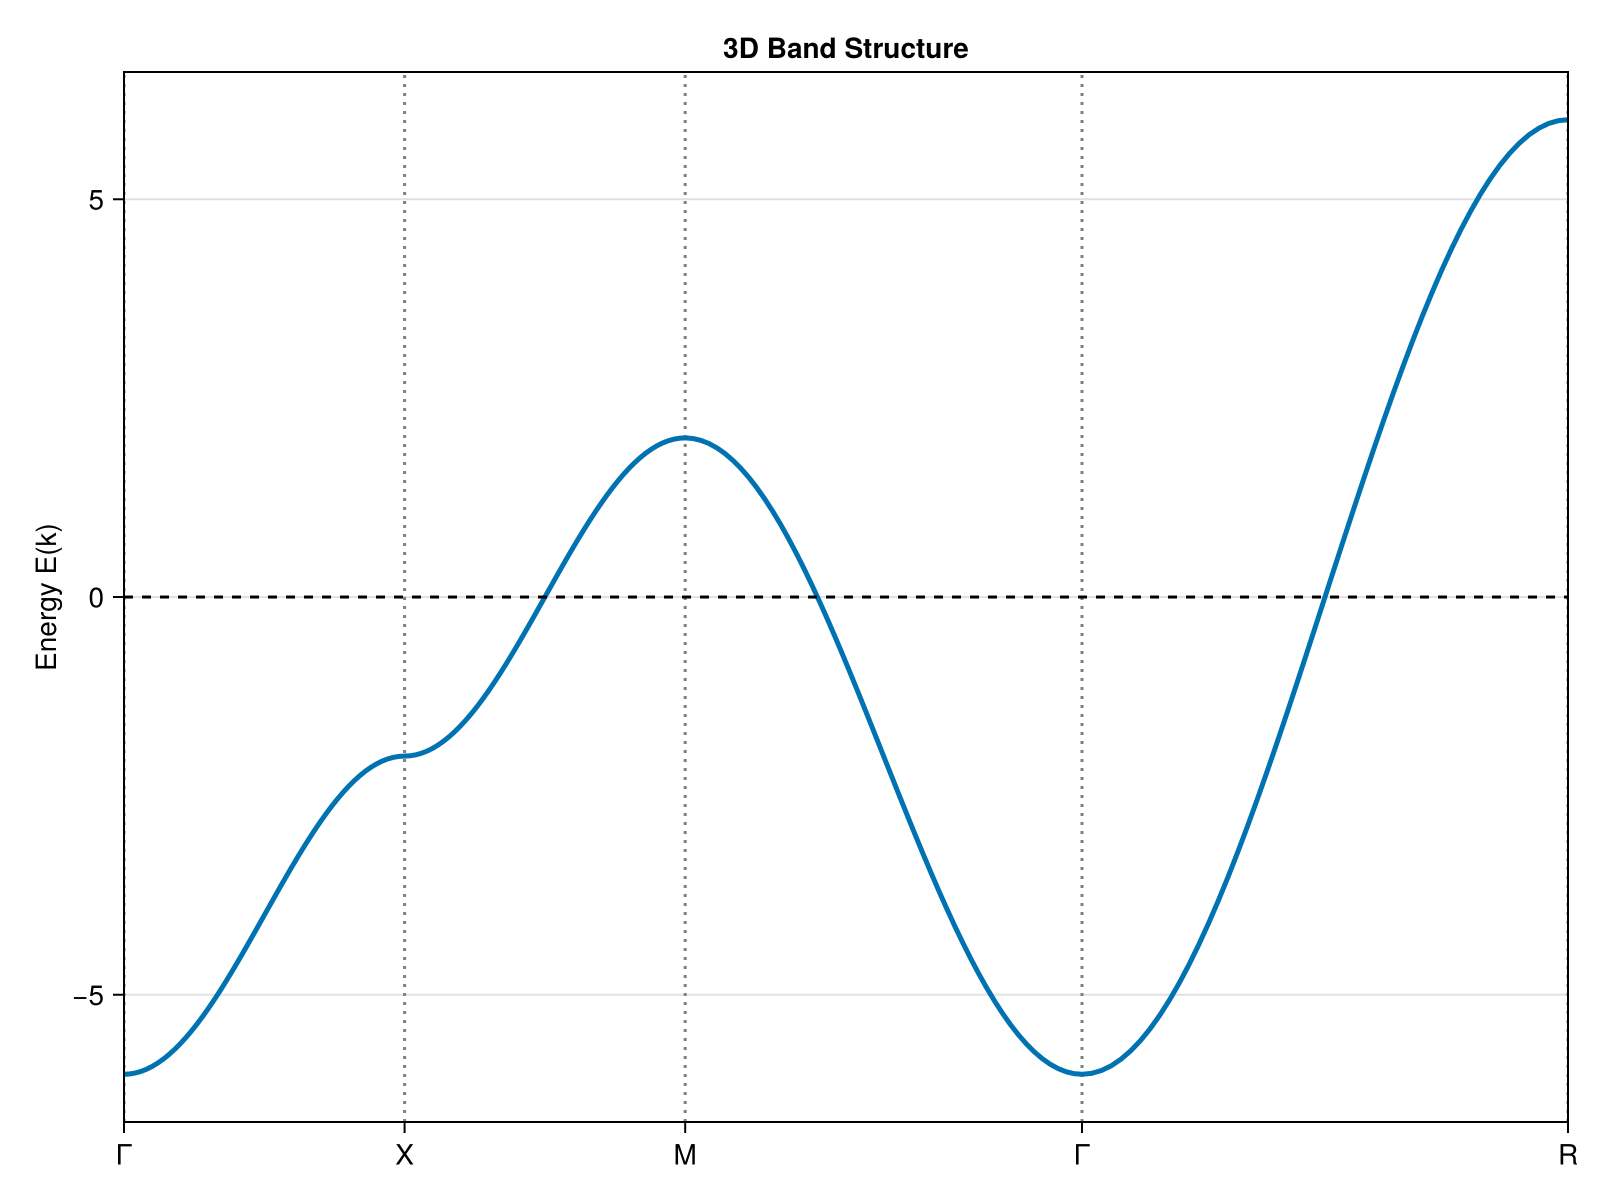

In [6]:
visualize_dispersion(tb_model, path)

┌ Warning: Volume{Tuple{Makie.EndPoints{Float64}, Makie.EndPoints{Float64}, Makie.EndPoints{Float64}, Array{Float32, 3}}} is not supported by cairo right now
└ @ CairoMakie /home/yimzhang/.julia/packages/CairoMakie/ohA3a/src/plot-primitives.jl:191
┌ Warning: Volume{Tuple{Makie.EndPoints{Float64}, Makie.EndPoints{Float64}, Makie.EndPoints{Float64}, Array{Float32, 3}}} is not supported by cairo right now
└ @ CairoMakie /home/yimzhang/.julia/packages/CairoMakie/ohA3a/src/plot-primitives.jl:191


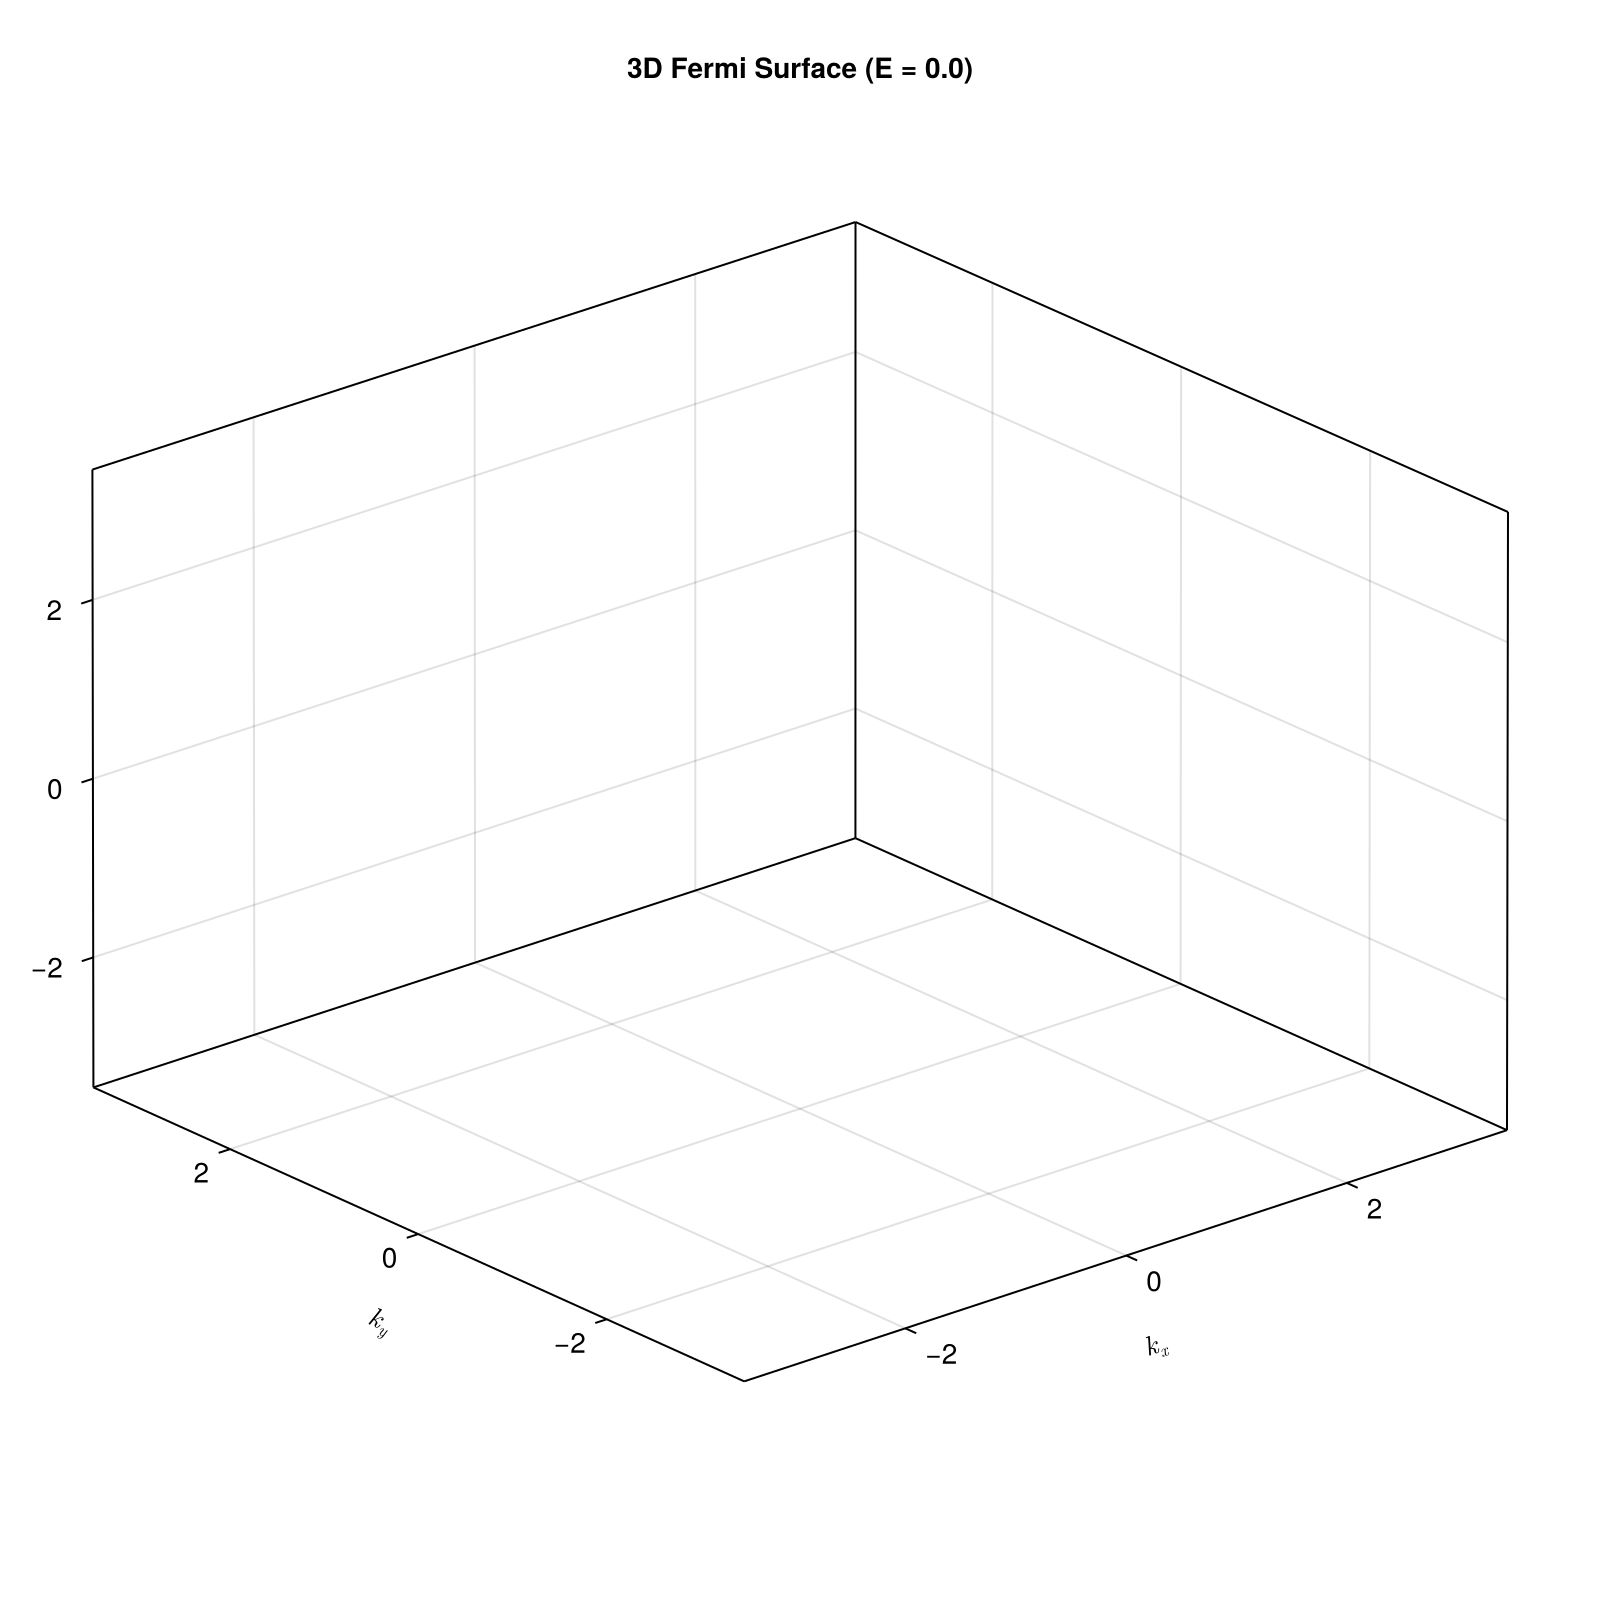

In [7]:

visualize_dispersion(tb_model, grid_3d; E_Fermi=0.0)